# Market Microstructure Simulator + ML Execution

Goal: simulate a toy limit order book, learn a short-horizon signal from order flow, and compare execution strategies (TWAP/VWAP/Almgren–Chriss vs. ML-adaptive).

## Setup

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Add current directory to path so we can import local modules
ROOT = Path().resolve()
sys.path.insert(0, str(ROOT))

from simulator import LOBSimulator
from ml import make_features, time_split, train_model, evaluate_model
from strategies import twap_schedule, vwap_schedule, ac_schedule, ml_adaptive_schedule
from evaluation import simulate_execution


## 1) Simulate a stylized limit order book

We tune the simulator to make the signal *learnable*: imbalance and order flow influence the next tick direction more strongly.

In [2]:
sim = LOBSimulator(
    seed=7,
    k_imbalance=3.5,
    k_ofi=0.12,
)
df = sim.simulate(num_steps=3000)
df.head()


,mid,spread,imbalance,ofi,volume,return,bid_depth_1,ask_depth_1,bid_depth_2,ask_depth_2,bid_depth_3,ask_depth_3
t,,,,,,,,,,,,
0,99.99,0.021667,-0.292365,-3,6,-0.0001,265.996466,453.890897,101.962606,302.734130,146.178079,182.352756
1,100.00,0.021523,-0.050054,4,5,0.0001,572.132356,467.547354,145.127613,334.044620,89.247721,89.907483
2,100.01,0.021523,0.014345,-2,5,0.0001,550.850390,440.403773,226.373727,159.849137,126.296104,277.712026
3,100.00,0.021328,0.013806,-3,4,-0.0001,578.069768,463.058327,263.655149,292.682616,180.321961,238.468620
4,100.01,0.021843,0.047136,0,8,0.0001,590.868421,477.412569,199.152121,230.704178,345.944589,325.580206


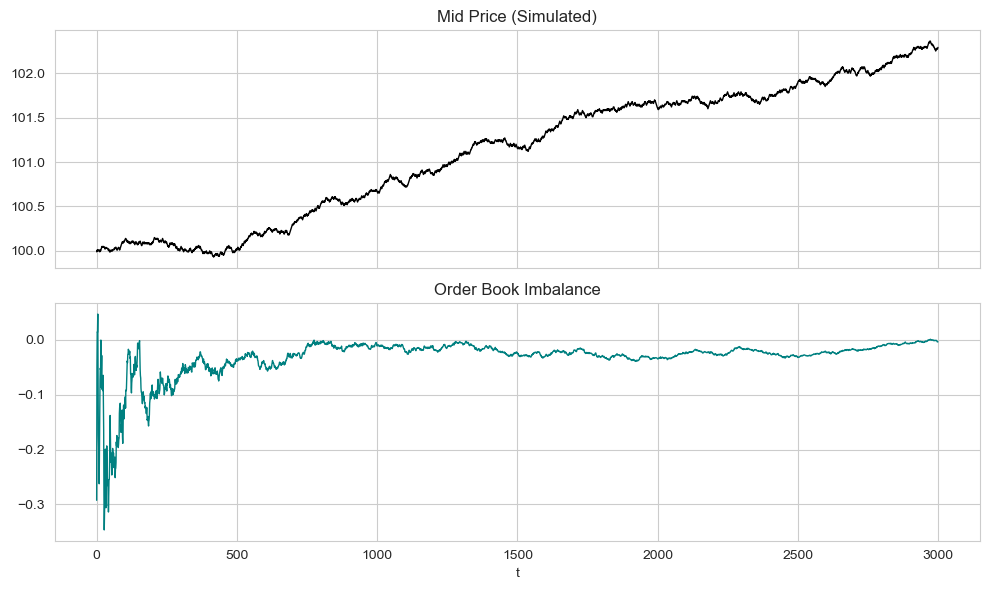

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
df['mid'].plot(ax=axes[0], color='black', lw=1)
axes[0].set_title('Mid Price (Simulated)')
df['imbalance'].plot(ax=axes[1], color='teal', lw=1)
axes[1].set_title('Order Book Imbalance')
plt.tight_layout()
plt.show()


### Signal check (does imbalance help?)

/var/folders/jz/5rgl2c9j3n3d8s8vg457h7x80000gn/T/ipykernel_71788/3291747576.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p_up = tmp.groupby('imb_bin')['next_return'].apply(lambda x: (x > 0).mean())


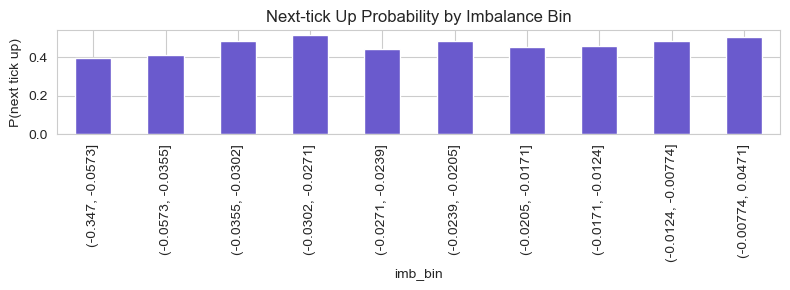

In [4]:
tmp = df.copy()
tmp['next_return'] = tmp['mid'].shift(-1) - tmp['mid']
tmp['imb_bin'] = pd.qcut(tmp['imbalance'], 10, duplicates='drop')
p_up = tmp.groupby('imb_bin')['next_return'].apply(lambda x: (x > 0).mean())
plt.figure(figsize=(8, 3))
p_up.plot(kind='bar', color='slateblue')
plt.ylabel('P(next tick up)')
plt.title('Next-tick Up Probability by Imbalance Bin')
plt.tight_layout()
plt.show()


## 2) Train an ML model for next-tick direction

In [5]:
X, y = make_features(df, horizon=1)
X_train, y_train, X_val, y_val, X_test, y_test = time_split(X, y)

model = train_model(X_train, y_train)
train_metrics = evaluate_model(model, X_train, y_train)
test_metrics = evaluate_model(model, X_test, y_test)

print('Train accuracy:', round(train_metrics['accuracy'], 3))
print('Train AUC:', round(train_metrics['auc'], 3))
print('Test accuracy:', round(test_metrics['accuracy'], 3))
print('Test AUC:', round(test_metrics['auc'], 3))


Train accuracy: 0.537
Train AUC: 0.557
Test accuracy: 0.536
Test AUC: 0.451


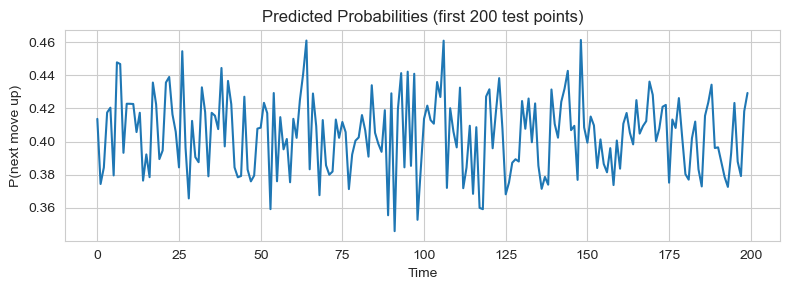

In [6]:
plt.figure(figsize=(8, 3))
plt.plot(test_metrics['probs'][:200], lw=1.5)
plt.title('Predicted Probabilities (first 200 test points)')
plt.ylabel('P(next move up)')
plt.xlabel('Time')
plt.tight_layout()
plt.show()


## 3) Compare execution strategies

We compare TWAP, VWAP, Almgren–Chriss, and an ML-adaptive schedule that trades more when P(up) is high.

In [7]:
exec_steps = 200
exec_idx = X_test.index[-exec_steps:]
df_exec = df.loc[exec_idx]
probs_exec = test_metrics['probs'][-exec_steps:]

total_qty = 10000
twap = twap_schedule(total_qty, exec_steps)
vwap = vwap_schedule(total_qty, df_exec['volume'].to_numpy())
ac = ac_schedule(total_qty, exec_steps, kappa=0.05)
ml = ml_adaptive_schedule(total_qty, twap, probs_exec, aggressiveness=0.6)

results = {
    'TWAP': simulate_execution(df_exec, twap),
    'VWAP': simulate_execution(df_exec, vwap),
    'Almgren-Chriss': simulate_execution(df_exec, ac),
    'ML-Adaptive': simulate_execution(df_exec, ml),
}

summary = pd.DataFrame({
    k: {
        'avg_price': v['avg_price'],
        'shortfall': v['shortfall'],
        'slippage_bps': v['slippage_bps'],
    } for k, v in results.items()
}).T
summary


,avg_price,shortfall,slippage_bps
TWAP,102.294506,2345.058916,22.977258
VWAP,102.291257,2312.573518,22.658961
Almgren-Chriss,102.247841,1878.411047,18.404968
ML-Adaptive,102.294522,2345.222792,22.978863


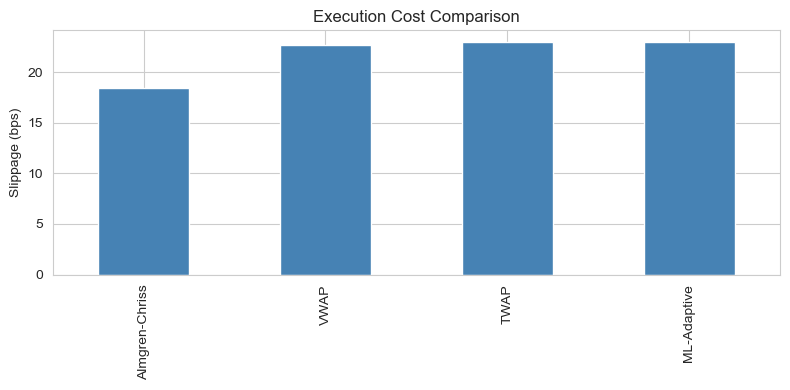

In [8]:
plt.figure(figsize=(8, 4))
summary['slippage_bps'].sort_values().plot(kind='bar', color='steelblue')
plt.ylabel('Slippage (bps)')
plt.title('Execution Cost Comparison')
plt.tight_layout()
plt.show()


### How ML shifts the schedule

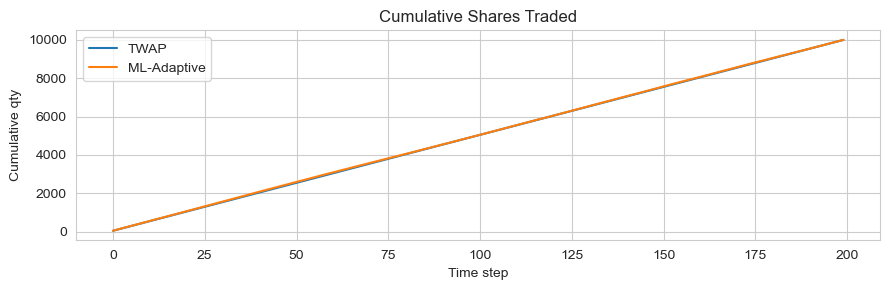

In [9]:
plt.figure(figsize=(9, 3))
plt.plot(np.cumsum(twap), label='TWAP', lw=1.5)
plt.plot(np.cumsum(ml), label='ML-Adaptive', lw=1.5)
plt.legend()
plt.title('Cumulative Shares Traded')
plt.xlabel('Time step')
plt.ylabel('Cumulative qty')
plt.tight_layout()
plt.show()


## Conclusion
- The simulator produces realistic order flow and price dynamics.
- Imbalance and order flow create a learnable short-horizon signal.
- Execution quality differs materially across strategies.

Interview angle: discuss microstructure assumptions, market impact, and why execution costs matter beyond backtest PnL.